<a href="https://colab.research.google.com/github/rjlobosco/unifesp/blob/main/aula_03_calculo_numerico_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 2 — Introdução ao Cálculo Numérico e Erros Computacionais

**Ambiente:** Python / Google Colab  
**Duração sugerida:** 2 horas  
**Público:** Graduação em Engenharias e Matemática  
**Versão:** notebook do aluno
## Objetivos de aprendizagem

Ao final da aula, você deverá ser capaz de:

- explicar por que soluções numéricas são necessárias em problemas de engenharia;
- distinguir valor de referência, aproximação, erro absoluto, relativo e percentual;
- reconhecer limitações da aritmética de ponto flutuante;
- diferenciar arredondamento de truncamento;
- identificar propagação de erros e perda de significância por cancelamento numérico;
- Conhecer um exemplo de cancelamento numérico no cálculo de estatísticas turbulentas.

> **Ideia central:** um resultado numérico deve vir acompanhado de informação sobre sua precisão, suas hipóteses e sua validade.

## 1. Preparação do ambiente

Usaremos três bibliotecas:

- `math`: constantes e funções matemáticas escalares;
- `numpy`: vetores, operações numéricas e representação de ponto flutuante;
- `matplotlib`: construção de gráficos.

Execute cada célula na ordem. Os comentários iniciados por `#` explicam os comandos Python.

In [ ]:
# Importa a biblioteca de funções matemáticas da linguagem Python.
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.
import numpy as np

# Importa o módulo de gráficos pyplot e cria o apelido plt.
import matplotlib.pyplot as plt

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Exibe uma mensagem para confirmar que a célula foi executada.
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


## 2. Por que precisamos do Cálculo Numérico?

Alguns problemas possuem solução analítica simples. Por exemplo, as raízes de $x^2-4=0$ são $x=\pm2$. Em muitos problemas reais, entretanto, a geometria, os dados experimentais ou as equações impedem uma solução fechada.

Considere a equação

$$f(x)=\cos(x)-x=0.$$

Ela aparece como um exemplo de **ponto fixo** e não é resolvida por manipulações algébricas elementares. O gráfico ajuda a localizar a raiz, mas não fornece sozinho uma aproximação com garantia de erro.

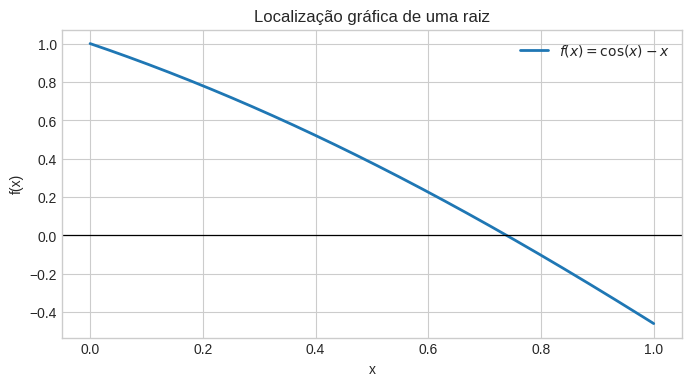

In [ ]:
# Define a função matemática que será estudada.
def f(x):
    # Calcula cos(x) - x e devolve o resultado.
    return np.cos(x) - x

# Cria 300 pontos igualmente espaçados no intervalo de 0 a 1.
x = np.linspace(0.0, 1.0, 300)

# Avalia a função f em todos os pontos do vetor x.
y = f(x)

# Cria uma figura com 8 polegadas de largura e 4 de altura.
plt.figure(figsize=(8, 4))

# Desenha o gráfico da função com espessura de linha igual a 2.
plt.plot(x, y, linewidth=2, label=r"$f(x)=\cos(x)-x$")

# Desenha a linha horizontal y = 0, que ajuda a localizar a raiz.
plt.axhline(0.0, color="black", linewidth=0.9)

# Identifica o eixo horizontal.
plt.xlabel("x")

# Identifica o eixo vertical.
plt.ylabel("f(x)")

# Adiciona um título ao gráfico.
plt.title("Localização gráfica de uma raiz")

# Exibe a legenda.
plt.legend()

# Mostra a figura na saída da célula.
plt.show()

### Discussão guiada

Analise o gráfico antes de responder:

1. Em qual intervalo a raiz parece estar?


## 3. Valor de referência e aproximação

Em aplicações, o chamado “valor exato” muitas vezes é apenas um **valor de referência**: uma medição mais precisa, uma solução analítica disponível ou um resultado computacional obtido com tolerância muito menor.

Vamos comparar $\pi$ com a aproximação $3{,}14$.

In [ ]:
# Obtém da biblioteca math um valor de alta precisão para pi.
valor_referencia = math.pi

# Armazena uma aproximação decimal de pi.
valor_aproximado = 3.14

# Exibe o valor usado como referência.
print("Valor de referência:", valor_referencia)

# Exibe o valor aproximado.
print("Valor aproximado:", valor_aproximado)

Valor de referência: 3.141592653589793
Valor aproximado: 3.14


## 4. Erros absoluto, relativo e percentual

Se $x$ é o valor de referência e $\tilde{x}$ é a aproximação, definimos:

$$E_a=|x-\tilde{x}|,$$

$$E_r=\frac{|x-\tilde{x}|}{|x|}, \qquad E_{\%}=100E_r.$$

- O **erro absoluto** tem a mesma unidade da grandeza.
- O **erro relativo** não tem unidade e considera a escala do problema.
- O **erro percentual** é o erro relativo expresso em porcentagem.

Quando $x=0$, a expressão usual do erro relativo não está definida.

In [ ]:
# Calcula a distância entre o valor de referência e a aproximação.
erro_absoluto = abs(valor_referencia - valor_aproximado)

# Divide o erro absoluto pelo módulo do valor de referência.
erro_relativo = erro_absoluto / abs(valor_referencia)

# Converte o erro relativo em porcentagem.
erro_percentual = 100.0 * erro_relativo

# Exibe o erro absoluto com dez casas decimais.
print(f"Erro absoluto:   {erro_absoluto:.10f}")

# Exibe o erro relativo em notação científica.
print(f"Erro relativo:   {erro_relativo:.6e}")

# Exibe o erro percentual com seis casas decimais.
print(f"Erro percentual: {erro_percentual:.6f}%")

Erro absoluto:   0.0015926536
Erro relativo:   5.069574e-04
Erro percentual: 0.050696%


### Atividade de interpretação

Use os resultados apresentados pela célula anterior para responder:

1. Qual é o erro absoluto da aproximação $3{,}14$ para $\pi$?
2. Qual é o erro relativo?
3. Qual é o erro percentual?
4. O erro absoluto e o erro relativo possuem a mesma unidade?

### Exemplo 1 — A escala muda a importância do erro

Um erro absoluto igual a 1 pode ser pequeno quando o valor de referência é 1000, mas muito grande quando o valor é 2.

In [ ]:
# Cria uma lista com pares formados por referência e aproximação.
casos = [(1000.0, 999.0), (2.0, 1.0)]

# Percorre cada par armazenado na lista.
for referencia, aproximacao in casos:
    # Calcula o erro absoluto do caso atual.
    erro_abs = abs(referencia - aproximacao)

    # Calcula o erro relativo do caso atual.
    erro_rel = erro_abs / abs(referencia)

    # Exibe os valores e o erro relativo em porcentagem.
    print(f"{referencia:g} → {aproximacao:g}: Ea={erro_abs:g}; E%={100*erro_rel:.1f}%")

1000 → 999: Ea=1; E%=0.1%
2 → 1: Ea=1; E%=50.0%


## 5. Algarismos significativos

Algarismos significativos expressam a precisão de uma medida ou aproximação. Zeros à esquerda não são significativos, mas os zeros entre algarismos não nulos são significativos. Assim, 0,00450 possui três algarismos significativos.

Uma regra útil é: se o erro relativo satisfaz

$$E_r < 5\times10^{-n},$$

então a aproximação possui, em uma convenção comum, pelo menos $n$ algarismos decimais significativos corretos. A regra exata pode variar conforme o texto adotado; o importante é sempre declarar o critério.

In [ ]:
# Cria diferentes aproximações para a raiz quadrada de 2.
aproximacoes = [1.4, 1.41, 1.414, 1.4142]

# Calcula um valor de referência para a raiz quadrada de 2.
referencia_raiz = math.sqrt(2.0)

# Percorre todas as aproximações da lista.
for aproximacao in aproximacoes:
    # Calcula o erro relativo de cada aproximação.
    erro_rel = abs(referencia_raiz - aproximacao) / abs(referencia_raiz)

    # Exibe a aproximação e seu erro relativo.
    print(f"Aproximação={aproximacao:<7} | erro relativo={erro_rel:.3e}")

Aproximação=1.4     | erro relativo=1.005e-02
Aproximação=1.41    | erro relativo=2.979e-03
Aproximação=1.414   | erro relativo=1.510e-04
Aproximação=1.4142  | erro relativo=9.590e-06


## 6. Representação de números no computador

O computador armazena números reais usando um conjunto finito de bits. Muitos decimais, como 0,1, não possuem representação binária finita. O valor armazenado é, portanto, o número representável mais próximo.

Isso não significa que o computador “calculou errado”; significa que a aritmética é feita com precisão finita.

In [ ]:
# Soma dois números que não têm representação binária finita.
resultado = 0.1 + 0.2

# Exibe o resultado com a representação padrão do Python.
print("0.1 + 0.2 =", resultado)

# Testa uma igualdade exata entre números de ponto flutuante.
print("Igualdade exata?", resultado == 0.3)

# Exibe a pequena diferença causada pela representação finita.
print("Diferença =", resultado - 0.3)

# Exibe o número com 18 casas para tornar a aproximação mais visível.
print(f"Resultado com 18 casas = {resultado:.18f}")

0.1 + 0.2 = 0.30000000000000004
Igualdade exata? False
Diferença = 5.551115123125783e-17
Resultado com 18 casas = 0.300000000000000044


### Comparações com tolerância

Em vez de exigir `a == b`, normalmente verificamos se $|a-b|$ é menor que uma tolerância. A função `math.isclose` combina tolerância relativa e absoluta.

In [ ]:
# Armazena a soma que desejamos testar.
a = 0.1 + 0.2

# Armazena o valor esperado.
b = 0.3

# Define uma tolerância absoluta pequena.
tolerancia = 1e-12

# Realiza uma comparação manual baseada na diferença absoluta.
comparacao_manual = abs(a - b) < tolerancia

# Realiza uma comparação robusta com tolerâncias relativa e absoluta.
comparacao_isclose = math.isclose(a, b, rel_tol=1e-12, abs_tol=1e-12)

# Exibe o resultado da comparação manual.
print("Comparação manual:", comparacao_manual)

# Exibe o resultado obtido com math.isclose.
print("Com math.isclose:", comparacao_isclose)

Comparação manual: True
Com math.isclose: True


### Limites da representação

`np.finfo` informa características do tipo `float64`: precisão de máquina, maior e menor número normal positivo representável. A **precisão de máquina** (`eps`) é a distância entre 1 e o próximo número representável maior que 1.

In [ ]:
# Obtém as propriedades numéricas do tipo float64.
info_float = np.finfo(np.float64)

# Exibe a precisão de máquina.
print("Epsilon de máquina:", info_float.eps)

# Exibe o maior número finito representável.
print("Maior float64:", info_float.max)

# Exibe o menor número normal positivo representável.
print("Menor float64 normal positivo:", info_float.tiny)

Epsilon de máquina: 2.220446049250313e-16
Maior float64: 1.7976931348623157e+308
Menor float64 normal positivo: 2.2250738585072014e-308


## 7. Arredondamento e truncamento

- **Arredondar** significa substituir um número pelo valor mais próximo na precisão desejada.
- **Truncar** significa descartar os algarismos após determinada posição.

Essas duas operações produzem erros de arredondamento. Mais adiante, “erro de truncamento” também será usado para o erro de substituir um processo infinito por um número finito de termos.

## Regra de arredondamento

O **arredondamento** consiste em substituir um número por outro com uma quantidade menor de algarismos, procurando manter o valor mais próximo possível do número original.

Para arredondar um número até determinada casa decimal, observamos o primeiro algarismo que será descartado.

### Regra usual de arredondamento

- Se o primeiro algarismo descartado for **menor que 5**, o último algarismo mantido permanece inalterado.
- Se o primeiro algarismo descartado for **maior que 5**, adicionamos uma unidade ao último algarismo mantido.
- Se o primeiro algarismo descartado for **igual a 5** e houver outros algarismos não nulos depois dele, adicionamos uma unidade ao último algarismo mantido.
- Quando o algarismo descartado é exatamente 5 e não há outros algarismos não nulos depois dele, a decisão depende da convenção de arredondamento adotada.

### Exemplos

Arredondando para duas casas decimais:

$$
3{,}14159 \approx 3{,}14
$$

Nesse caso, o primeiro algarismo descartado é 1. Como $1<5$, a segunda casa decimal permanece inalterada.

$$
2{,}71828 \approx 2{,}72
$$

Nesse exemplo, o primeiro algarismo descartado é 8. Como $8>5$, adicionamos uma unidade à segunda casa decimal.

$$
5{,}236 \approx 5{,}24
$$

O primeiro algarismo descartado é 6. Portanto, o algarismo 3 é aumentado para 4.

### Arredondamento em Python

Em Python, a função `round()` pode ser utilizada para arredondar um número:

```python
round(numero, casas_decimais)


In [ ]:
# Define uma função para truncar um número em determinada quantidade de casas.
def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator

# Armazena pi como número de teste.
numero = math.pi

# Exibe o valor original.
print("Valor original:", numero)

# Arredonda o valor para três casas decimais.
print("Arredondado:", round(numero, 3))

# Trunca o valor para três casas decimais.
print("Truncado:", truncar(numero, 3))

## 8. Propagação de erros nas operações

Se os dados de entrada contêm pequenas incertezas, as operações propagam essas incertezas. Em produtos e potências, o erro relativo pode crescer rapidamente.

Para $y=x^n$, uma aproximação de primeira ordem fornece

$$\frac{|\Delta y|}{|y|}\approx |n|\frac{|\Delta x|}{|x|}.$$

Vamos verificar isso para o volume de uma esfera, $V=\frac{4}{3}\pi r^3$.

In [ ]:
# Define o raio de referência em centímetros.
raio_referencia = 1.000

# Define um raio medido com erro de 1%.
raio_medido = 1.010

# Calcula o volume usando o raio de referência.
volume_referencia = (4.0 / 3.0) * math.pi * raio_referencia ** 3

# Calcula o volume usando o raio medido.
volume_medido = (4.0 / 3.0) * math.pi * raio_medido ** 3

# Calcula o erro relativo do raio.
erro_rel_raio = abs(raio_medido - raio_referencia) / raio_referencia

# Calcula o erro relativo do volume.
erro_rel_volume = abs(volume_medido - volume_referencia) / volume_referencia

# Exibe o erro percentual do raio.
print(f"Erro no raio: {100*erro_rel_raio:.3f}%")

# Exibe o erro percentual propagado para o volume.
print(f"Erro no volume: {100*erro_rel_volume:.3f}%")

Erro no raio: 1.000%
Erro no volume: 3.030%


### Questões para discussão

1. Qual foi o erro percentual introduzido na medida do raio?
2. Qual foi o erro percentual observado no volume?
3. Por que o erro no volume é aproximadamente três vezes maior?
4. A aproximação linear fornece exatamente o mesmo resultado do cálculo completo?

## 9 Perda de significância por cancelamento numérico

Subtrair dois números muito próximos pode eliminar algarismos significativos. Um exemplo clássico ocorre em

$$g(x)=\sqrt{x+1}-\sqrt{x}.$$

Para $x$ grande, os dois termos são quase iguais. Racionalizando,

$$g(x)=\frac{1}{\sqrt{x+1}+\sqrt{x}},$$

obtemos uma forma numericamente mais estável.

In [ ]:
# Define um valor grande de x para provocar cancelamento.
x_grande = 1e16

# Calcula a expressão diretamente por subtração.
forma_direta = math.sqrt(x_grande + 1.0) - math.sqrt(x_grande)

# Calcula a expressão equivalente na forma racionalizada.
forma_estavel = 1.0 / (math.sqrt(x_grande + 1.0) + math.sqrt(x_grande))

# Exibe o resultado da forma suscetível a cancelamento.
print("Forma direta:", forma_direta)

# Exibe o resultado da forma numericamente estável.
print("Forma estável:", forma_estavel)

Forma direta: 0.0
Forma estável: 5e-09


## 9.1 Exemplo clássico: diferença entre raízes quadradas

Considere

$$g(x)=\sqrt{x+1}-\sqrt{x}.$$

Para valores grandes de $x$, as duas raízes quadradas são muito próximas. A subtração pode perder precisão.

Podemos multiplicar numerador e denominador pelo conjugado:

$$g(x)=\frac{(\sqrt{x+1}-\sqrt{x})(\sqrt{x+1}+\sqrt{x})}
{\sqrt{x+1}+\sqrt{x}}.$$

No numerador,

$$(x+1)-x=1.$$

Assim,

$$g(x)=\frac{1}{\sqrt{x+1}+\sqrt{x}}.$$

Essa segunda forma evita a subtração entre números próximos.

In [ ]:
# Define a fórmula direta.
def forma_direta(x):
    return math.sqrt(x + 1.0) - math.sqrt(x)

# Define a fórmula racionalizada.
def forma_estavel(x):
    return 1.0 / (math.sqrt(x + 1.0) + math.sqrt(x))

# Compara as duas formas para diferentes valores de x.
for x in [1.0, 1e4, 1e8, 1e12, 1e16]:
    resultado_direto = forma_direta(x)
    resultado_estavel = forma_estavel(x)

    print(f"x = {x:.0e}")
    print(f"  Forma direta: {resultado_direto:.16e}")
    print(f"  Forma estável: {resultado_estavel:.16e}")

### Interpretação

Para $x=10^{16}$, o computador pode considerar $x+1$ igual a $x$ na representação em ponto flutuante. Nesse caso, a forma direta produz zero.

A forma racionalizada continua fornecendo um valor pequeno diferente de zero.

> As duas fórmulas são equivalentes na matemática exata, mas podem produzir resultados diferentes no computador.

## 9.2. Outro exemplo simples: $1-\cos(x)$

Quando $x$ é muito pequeno, $\cos(x)$ é muito próximo de 1. A expressão

$$1-\cos(x)$$

subtrai números próximos.

Podemos usar a identidade

$$1-\cos(x)=2\sin^2\left(\frac{x}{2}\right).$$

A segunda forma evita a subtração crítica.

In [ ]:
# Define a forma direta.
def um_menos_cosseno_direto(x):
    return 1.0 - math.cos(x)

# Define a forma baseada na identidade trigonométrica.
def um_menos_cosseno_estavel(x):
    return 2.0 * math.sin(x / 2.0) ** 2

# Compara as duas formas.
for x in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    direto = um_menos_cosseno_direto(x)
    estavel = um_menos_cosseno_estavel(x)

    print(
        f"x={x:.0e} | direta={direto:.16e} | "
        f"estável={estavel:.16e}"
    )

### Atividade 1 — construindo um gráfico

O código abaixo representa os resultados das duas fórmulas para diferentes valores de $x$.

Observe em qual região a forma direta começa a se afastar da forma estável.

In [ ]:
# Cria valores de x entre 10⁻¹ e 10⁻¹⁰.
valores_x = np.logspace(-1, -10, 100)

# Calcula a forma direta usando NumPy.
resultados_diretos = 1.0 - np.cos(valores_x)

# Calcula a forma estável.
resultados_estaveis = 2.0 * np.sin(valores_x / 2.0) ** 2

# Constrói o gráfico em escala logarítmica.
plt.figure(figsize=(8, 4.5))
plt.loglog(valores_x, resultados_diretos, label="Forma direta")
plt.loglog(valores_x, resultados_estaveis, "--", label="Forma estável")
plt.xlabel("x")
plt.ylabel("Resultado")
plt.title("Comparação entre duas formas equivalentes")
plt.legend()
plt.show()

##  Como reduzir problemas de cancelamento?

Algumas estratégias simples são:

1. evitar subtrair números muito próximos quando existe outra fórmula;
2. racionalizar diferenças que envolvem raízes;
3. utilizar identidades matemáticas equivalentes;
4. não arredondar valores intermediários cedo demais;
5. manter mais casas durante o cálculo e arredondar apenas o resultado final;
6. comparar o resultado com outra formulação quando houver dúvida.

## 10. Atividade prática — precisão das aproximações

Compare aproximações arredondadas de $\sqrt{2}$, $\pi$ e $e$, usando 1, 2, 4 e 6 casas decimais.

Para cada aproximação:

1. calcule o erro absoluto;
2. calcule o erro relativo;
3. observe o efeito de aumentar o número de casas decimais;
4. compare os resultados das três constantes.

In [ ]:
# Importa a biblioteca math caso esta célula seja executada separadamente.
import math

# Cria um dicionário com os valores de referência.
valores = {
    "raiz de 2": math.sqrt(2.0),
    "pi": math.pi,
    "e": math.e
}

# Define as quantidades de casas decimais que serão avaliadas.
casas_testadas = [1, 2, 4, 6]

# Percorre cada constante armazenada no dicionário.
for nome, referencia in valores.items():
    # Exibe um título para identificar a constante analisada.
    print(f"\n--- {nome} ---")

    # Percorre cada quantidade de casas decimais.
    for casas in casas_testadas:
        # TODO: use round para calcular a aproximação.
        aproximacao = None

        # TODO: calcule o erro absoluto.
        erro_abs = None

        # TODO: calcule o erro relativo.
        erro_rel = None

        # Exibe os valores preenchidos pelo estudante.
        print(
            f"casas={casas} | aproximação={aproximacao} | "
            f"erro absoluto={erro_abs} | erro relativo={erro_rel}"
        )


--- raiz de 2 ---
casas=1 | aproximação=None | erro absoluto=None | erro relativo=None
casas=2 | aproximação=None | erro absoluto=None | erro relativo=None
casas=4 | aproximação=None | erro absoluto=None | erro relativo=None
casas=6 | aproximação=None | erro absoluto=None | erro relativo=None

--- pi ---
casas=1 | aproximação=None | erro absoluto=None | erro relativo=None
casas=2 | aproximação=None | erro absoluto=None | erro relativo=None
casas=4 | aproximação=None | erro absoluto=None | erro relativo=None
casas=6 | aproximação=None | erro absoluto=None | erro relativo=None

--- e ---
casas=1 | aproximação=None | erro absoluto=None | erro relativo=None
casas=2 | aproximação=None | erro absoluto=None | erro relativo=None
casas=4 | aproximação=None | erro absoluto=None | erro relativo=None
casas=6 | aproximação=None | erro absoluto=None | erro relativo=None


### Análise dos resultados

Após completar e executar o código, responda:

1. O erro sempre diminui quando mais casas decimais são mantidas?
2. A redução ocorre na mesma proporção em todos os casos?
3. Qual medida de erro é mais adequada para comparar números de magnitudes diferentes?

## 11. Desafio — construção de uma função reutilizável

Complete a função `calcular_erros(referencia, aproximacao)` para que ela devolva:

- erro absoluto;
- erro relativo;
- erro percentual.

Trate separadamente o caso em que o valor de referência é igual a zero.

In [ ]:
# Define uma função que receberá um valor de referência e uma aproximação.
def calcular_erros(referencia, aproximacao):
    # TODO: calcule o erro absoluto.
    erro_abs = None

    # Verifica se o valor de referência é igual a zero.
    if referencia == 0.0:
        # TODO: defina como tratar o erro relativo quando a referência é zero.
        erro_rel = None
    else:
        # TODO: calcule o erro relativo para uma referência diferente de zero.
        erro_rel = None

    # TODO: converta o erro relativo em erro percentual.
    erro_percentual = None

    # Devolve os três resultados calculados.
    return erro_abs, erro_rel, erro_percentual

# Teste 1: aproximação de pi.
print(calcular_erros(math.pi, 3.14))

# Teste 2: referência igual a zero.
print(calcular_erros(0.0, 0.01))

(None, None, None)
(None, None, None)


### Questão adicional

Quando a referência é zero, a fórmula usual do erro relativo envolve uma divisão por zero. Qual seria uma decisão computacional adequada: retornar infinito, `None`, `np.nan` ou gerar uma exceção? Justifique sua escolha.

## 12. Atividade final

Considere

$$f(x)=\frac{1-\cos(x)}{x^2}.$$

Para valores pequenos de $x$, o resultado deve se aproximar de $0{,}5$.

### Tarefas

1. Calcule a expressão diretamente para $x=10^{-2}$, $10^{-4}$, $10^{-6}$ e $10^{-8}$.
2. Substitua $1-\cos(x)$ por $2\sin^2(x/2)$.
3. Compare os resultados.
4. Identifique qual fórmula é mais confiável para valores pequenos de $x$.


In [ ]:
# Define a forma direta.
def f_direta(x):
    return (1.0 - math.cos(x)) / x ** 2

# Define a forma estável.
def f_estavel(x):
    return 2.0 * math.sin(x / 2.0) ** 2 / x ** 2

# ATIVIDADE FINAL — execute e interprete os resultados.
for x in [1e-2, 1e-4, 1e-6, 1e-8]:
    print(f"x={x:.0e}")
    print("  Forma direta:", f_direta(x))
    print("  Forma estável:", f_estavel(x))

## 12. Fechamento e avaliação rápida

Responda sem consultar as células anteriores:

1. Por que um resultado numérico deve vir acompanhado de uma estimativa de erro?
2. Quando o erro relativo é mais informativo do que o erro absoluto?
3. Por que números do tipo `float` não devem ser comparados apenas com `==`?
4. Qual é a diferença entre erro de arredondamento e erro de truncamento?
5. O que caracteriza a perda de significância por cancelamento numérico?

### Tarefa

Escolha uma grandeza de engenharia, proponha um valor de referência e duas aproximações, calcule os erros absoluto, relativo e percentual e interprete qual aproximação é mais adequada ao contexto.

## Referências sugeridas
1. BURDEN, R. L.; FAIRES, J. D. Análise numérica. 8a ed. São Paulo: Cengage Learning, 2008.
2. FRANCO, N. B. Cálculo numérico. São Paulo: Pearson, 2006.
3. RUGGIERO, M. A. G.; LOPES, V. L. R. Cálculo numérico – aspectos teóricos e computacionais. 2a ed. São Paulo: Pearson, 2008.


## Anexo 1 — Perda de significância por cancelamento numérico em turbulência

Em análises de escoamentos turbulentos, a perda de significância pode ocorrer quando uma grandeza pequena é calculada pela subtração de duas quantidades grandes e muito próximas.

### Decomposição de Reynolds

A velocidade instantânea pode ser representada por:

$$
u(t)=\overline{u}+u^{\prime}(t)
$$

em que:

- $u(t)$ é a velocidade instantânea;
- $\overline{u}$ é a velocidade média;
- $u^{\prime}(t)$ é a flutuação turbulenta.

Consequentemente,

$$
u^{\prime}(t)=u(t)-\overline{u}
$$

### Variância das flutuações

A variância pode ser calculada diretamente pelas flutuações:

$$
\overline{\left(u^{\prime}\right)^2}
=
\overline{\left(u-\overline{u}\right)^2}
$$

Uma expressão matematicamente equivalente é:

$$
\overline{\left(u^{\prime}\right)^2}
=
\overline{u^2}-\left(\overline{u}\right)^2
$$

Quando as flutuações são pequenas, $\overline{u^2}$ e $\left(\overline{u}\right)^2$ são números grandes e próximos. A subtração direta pode, portanto, perder algarismos significativos.

### Energia cinética turbulenta

A energia cinética turbulenta por unidade de massa é definida por:

$$
k=
\frac{1}{2}
\left[
\overline{\left(u^{\prime}\right)^2}
+
\overline{\left(v^{\prime}\right)^2}
+
\overline{\left(w^{\prime}\right)^2}
\right]
$$

Erros no cálculo das variâncias podem contaminar a estimativa de $k$ e até produzir valores ligeiramente negativos para grandezas que deveriam ser não negativas.

In [ ]:
# Importa a biblioteca NumPy para trabalhar com vetores e cálculos numéricos.
import numpy as np

# Cria um gerador de números aleatórios com uma semente fixa.
# A semente permite reproduzir exatamente os mesmos resultados.
gerador = np.random.default_rng(seed=10)

# Define uma velocidade média muito elevada.
# Esse valor exagerado é utilizado apenas para evidenciar o cancelamento numérico.
velocidade_media = 1.0e8

# Define o desvio-padrão das flutuações turbulentas.
# As flutuações são muito pequenas em comparação com a velocidade média.
desvio_flutuacoes = 1.0

# Define a quantidade de amostras que será gerada.
numero_amostras = 1_000_000

# Gera flutuações turbulentas com distribuição normal.
# A média das flutuações é aproximadamente zero.
flutuacoes_originais = gerador.normal(
    loc=0.0,
    scale=desvio_flutuacoes,
    size=numero_amostras
)

# Constrói o sinal de velocidade instantânea.
# Cada valor é formado pela velocidade média mais uma pequena flutuação.
u = velocidade_media + flutuacoes_originais

# Calcula a média das velocidades instantâneas.
u_media = np.mean(u)

# Calcula o primeiro termo da expressão instável: média de u ao quadrado.
media_dos_quadrados = np.mean(u**2)

# Calcula o segundo termo da expressão instável: quadrado da média de u.
quadrado_da_media = u_media**2

# Calcula a variância pela diferença entre dois números grandes e próximos.
# Essa forma é matematicamente correta, mas suscetível ao cancelamento numérico.
variancia_instavel = media_dos_quadrados - quadrado_da_media

# Calcula as flutuações em relação à média obtida numericamente.
u_linha = u - u_media

# Calcula a variância diretamente a partir das flutuações.
# Essa formulação é numericamente mais estável.
variancia_estavel = np.mean(u_linha**2)

# Calcula a variância usando a função implementada pelo NumPy.
variancia_numpy = np.var(u)

# Exibe a velocidade média calculada.
print(f"Velocidade média: {u_media:.10e}")

# Exibe os dois números grandes utilizados na subtração.
print(f"Média dos quadrados: {media_dos_quadrados:.16e}")
print(f"Quadrado da média:   {quadrado_da_media:.16e}")

# Exibe a variância calculada pela formulação suscetível ao cancelamento.
print(f"\nVariância pela forma instável: {variancia_instavel:.16e}")

# Exibe a variância calculada diretamente pelas flutuações.
print(f"Variância pela forma estável:  {variancia_estavel:.16e}")

# Exibe o resultado produzido pela função de variância do NumPy.
print(f"Variância calculada por np.var: {variancia_numpy:.16e}")

# Calcula a diferença absoluta entre as duas formulações.
diferenca_absoluta = abs(variancia_instavel - variancia_estavel)

# Exibe a diferença absoluta entre os resultados.
print(f"\nDiferença absoluta: {diferenca_absoluta:.16e}")

# Verifica se a variância instável é negativa.
# Uma variância negativa indicaria um resultado numericamente inconsistente.
if variancia_instavel < 0.0:
    # Exibe um aviso caso a inconsistência seja identificada.
    print("Atenção: a forma instável produziu uma variância negativa.")
else:
    # Informa que o resultado não foi negativo nesta execução.
    print("A forma instável não produziu valor negativo nesta execução.")

Velocidade média: 9.9999999999e+07
Média dos quadrados: 9.9999999997231940e+15
Quadrado da média:   9.9999999997231940e+15

Variância pela forma instável: 0.0000000000000000e+00
Variância pela forma estável:  1.0012194059878512e+00
Variância calculada por np.var: 1.0012194059878512e+00

Diferença absoluta: 1.0012194059878512e+00
A forma instável não produziu valor negativo nesta execução.


### Interpretação dos resultados

A formulação

$$
\overline{u^2}-\left(\overline{u}\right)^2
$$

subtrai dois números grandes e próximos. Por isso, erros de arredondamento podem se tornar relevantes.

A formulação

$$
\overline{\left(u-\overline{u}\right)^2}
$$

calcula primeiro as pequenas flutuações e depois seus quadrados, apresentando maior estabilidade numérica.

### Questões para discussão

1. Por que expressões matematicamente equivalentes podem produzir resultados numéricos diferentes?
2. Como a razão entre a velocidade média e as flutuações influencia o cancelamento?
3. Como uma variância incorreta afetaria a energia cinética turbulenta?
4. O uso de precisão dupla elimina completamente o problema?
5. Como esse fenômeno pode afetar o pós-processamento de resultados de CFD?